<a href="https://colab.research.google.com/github/DilemmaFixer3/svgm_labs/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install rdflib networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 7.8 MB/s eta 0:00:00


In [5]:
from rdflib import Graph, Literal, RDF, URIRef
from rdflib.namespace import DC, XSD

# 1. Створюємо RDF-граф
g = Graph()

# 2. Оголошуємо URI для книги та автора
book = URIRef("http://example.org/book/Kobzar")
author = URIRef("http://example.org/author/TarasShevchenko")

# 3. Додаємо тріплети (Суб'єкт, Предикат, Об'єкт)
# Книга є ресурсом
g.add((book, RDF.type, URIRef("http://purl.org/dc/terms/BibliographicResource")))
# Назва книги
g.add((book, DC.title, Literal("Кобзар")))
# Автор книги (посилання на URI автора)
g.add((book, DC.creator, author))
# Ім'я автора як літерал для його сутності
g.add((author, DC.title, Literal("Тарас Шевченко")))
# Дата публікації
g.add((book, DC.date, Literal("1840", datatype=XSD.gYear)))

# 4. Зберігаємо у файл RDF/XML
g.serialize("book.rdf", format="xml")
print("RDF-файл 'book.rdf' успішно створено!")

RDF-файл 'book.rdf' успішно створено!


In [6]:
# Формуємо простий HTML-документ із семантичною розміткою RDFa
html_content = """<!DOCTYPE html>
<html lang="uk">
<head>
    <meta charset="UTF-8">
    <title>Семантичний опис книги</title>
</head>
<body>
    <div vocab="http://purl.org/dc/elements/1.1/"
         about="http://example.org/book/Kobzar"
         typeof="http://purl.org/dc/terms/BibliographicResource">

        <h1 property="title">Кобзар</h1>

        <p>Автор:
            <span property="creator" resource="http://example.org/author/TarasShevchenko">
                Тарас Шевченко
            </span>
        </p>

        <p>Рік публікації: <span property="date">1840</span></p>
    </div>
</body>
</html>
"""

# Записуємо у файл
with open("book.html", "w", encoding="utf-8") as file:
    file.write(html_content)

print("Файл 'book.html' з розміткою RDFa успішно згенеровано!")

Файл 'book.html' з розміткою RDFa успішно згенеровано!


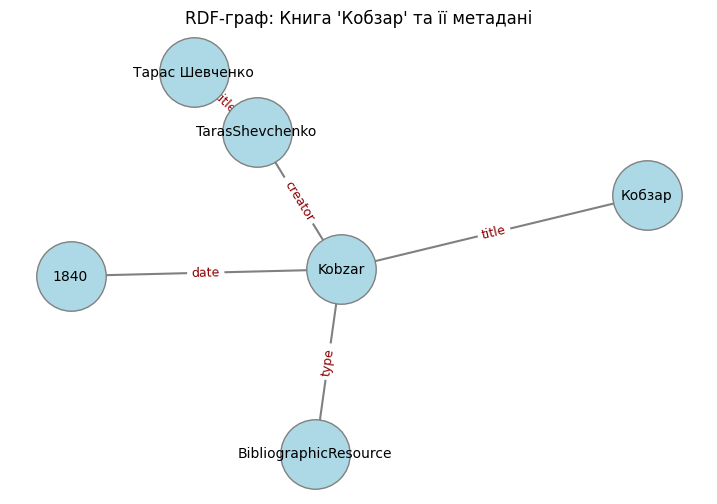

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Створюємо орієнтований граф NetworkX
G = nx.DiGraph()

# Проста функція для скорочення посилань для красивих підписів
def short_name(val):
    val_str = str(val)
    if "#" in val_str:
        return val_str.split("#")[-1]
    return val_str.split("/")[-1]

# 2. Додаємо ребра та вершини з RDF-графа
for subj, pred, obj in g:
    u = short_name(subj)
    v = short_name(obj)
    label = short_name(pred)
    G.add_edge(u, v, label=label)

# 3. Візуалізація
plt.figure(figsize=(9, 6))
pos = nx.spring_layout(G, seed=42)

# Вершини
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2500, edgecolors="gray")

# Зв'язки (стрілки)
nx.draw_networkx_edges(G, pos, edge_color="gray", arrowstyle="->", arrowsize=18, width=1.5)

# Текст вузлів
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

# Текст ребер (предикати: title, creator, date, type)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="darkred", font_size=9)

plt.title("RDF-граф: Книга 'Кобзар' та її метадані")
plt.axis("off")
plt.show()